# 03 — Isolation Forest Validasyon & Skorlama

Model gerçekten öğrenmesi gerekeni öğrendi mi?

| Bölüm | Soru |
|---|---|
| 1 | Artifact yükle, skor dağılımı sağlıklı mı? |
| 2 | Eşik analizi — kaç post/author şüpheli? |
| 3 | Bilinen bot (0a92fab3) düşük skor aldı mı? |
| 4 | Feature → skor monotonluk kontrolü |
| 5 | Stabilite testi — seed değişince sonuçlar kayıyor mu? |
| 6 | Aynı author'ın postları tutarlı skor alıyor mu? |
| 7 | Top-1000 bot profili |
| 8 | Feature–skor korelasyon (vekil önem analizi) |

## 0. Setup & Artifact Yükleme

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

MODELS_DIR    = Path("../models/task_1")
OUTPUTS_DIR   = Path("../outputs")
PROCESSED_DIR = Path("../data/processed")

# model.py ile sync — burası tek kaynak olmalı
IF_FEATURES = [
    "text_len",
    "kw_count",
    "kw_density",
    "sentiment",
    "sentiment_extreme",
    "is_duplicate",
    "has_author",
    "cross_author_dup_count",
    "kw_fingerprint_shared",
    "author_posts_per_day",
    "author_min_interval_sec",
    "author_mean_jaccard",
    "author_sentiment_std",
    "author_unique_themes",
    "author_duplicate_ratio",
]

LOG1P_FEATURES = [
    "text_len",
    "kw_count",
    "cross_author_dup_count",
    "kw_fingerprint_shared",
    "author_posts_per_day",
    "author_min_interval_sec",
    "author_unique_themes",
]

iso_forest    = joblib.load(MODELS_DIR / "isolation_forest.pkl")
scaler        = joblib.load(MODELS_DIR / "scaler.pkl")
minmax_scaler = joblib.load(MODELS_DIR / "minmax_scaler.pkl")

post_scores   = pd.read_parquet(OUTPUTS_DIR / "post_scores.parquet")
author_scores = pd.read_csv(OUTPUTS_DIR / "author_scores.csv")
top_bots      = pd.read_csv(OUTPUTS_DIR / "top_bots.csv")
post_df       = pd.read_parquet(PROCESSED_DIR / "post_features.parquet")

print(f"post_scores    : {len(post_scores):,} satır, kolonlar: {list(post_scores.columns)}")
print(f"author_scores  : {len(author_scores):,} author, kolonlar: {list(author_scores.columns)}")
print(f"top_bots       : {len(top_bots):,} author")
print(f"post_df        : {len(post_df):,} satır")
print(f"\nIsolation Forest — n_estimators: {iso_forest.n_estimators}, max_samples: {iso_forest.max_samples_}")

post_scores    : 5,004,813 satır, kolonlar: ['author_hash', 'organic_score', 'timestamp', 'language', 'domain']
author_scores  : 1,597,836 author, kolonlar: ['author_hash', 'mean_organic_score', 'author_posts_per_day', 'author_min_interval_sec', 'author_unique_themes', 'author_duplicate_ratio', 'author_sentiment_std', 'author_mean_jaccard']
top_bots       : 1,000 author
post_df        : 5,004,813 satır

Isolation Forest — n_estimators: 300, max_samples: 10000


In [2]:
import pandas as pd
scores = pd.read_parquet(OUTPUTS_DIR / "post_scores.parquet")["organic_score"]
print(scores.describe())
print(scores.quantile([0.01, 0.05, 0.10, 0.25]))

count    5.004813e+06
mean     8.527589e-01
std      1.607558e-01
min      0.000000e+00
25%      8.105728e-01
50%      9.098766e-01
75%      9.585530e-01
max      1.000000e+00
Name: organic_score, dtype: float64
0.01    0.200410
0.05    0.519063
0.10    0.649389
0.25    0.810573
Name: organic_score, dtype: float64


## 1. Skor Dağılımı

,percentile,post_score,author_score
0,0,0.0000,0.0000
1,1,0.2004,0.2912
2,5,0.5191,0.6094
3,10,0.6494,0.7251
4,25,0.8106,0.8497
5,50,0.9099,0.9500
6,75,0.9586,0.9789
7,90,0.9774,0.9898
8,95,0.9857,0.9939
9,99,0.9956,0.9984


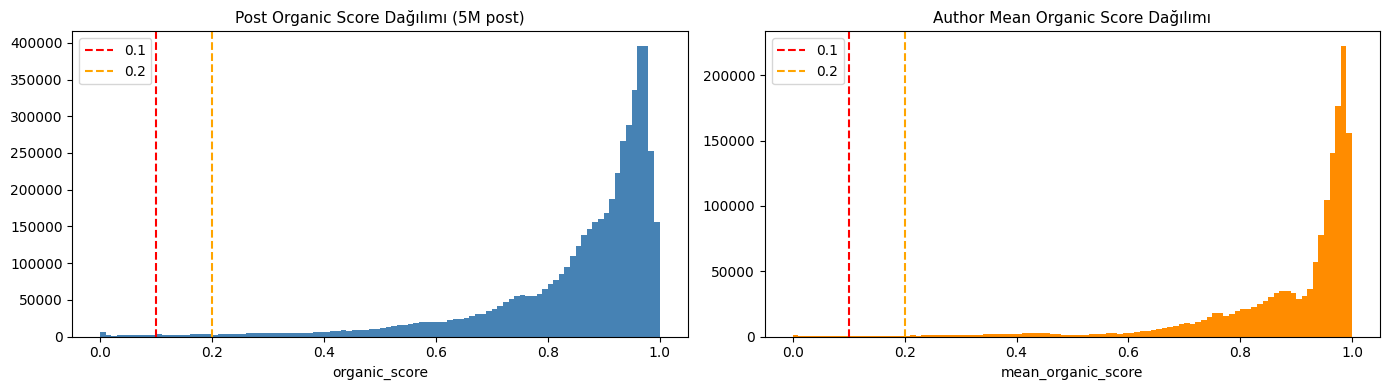


Post score   — mean: 0.8528  std: 0.1608
Author score — mean: 0.8889  std: 0.1443


In [3]:
# Percentile tablosu
pcts = [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]
post_pct   = np.percentile(post_scores["organic_score"], pcts)
author_pct = np.percentile(author_scores["mean_organic_score"], pcts)

pct_df = pd.DataFrame({
    "percentile": pcts,
    "post_score": post_pct.round(4),
    "author_score": author_pct.round(4),
})
display(pct_df)

# Histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(post_scores["organic_score"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_title("Post Organic Score Dağılımı (5M post)", fontsize=11)
axes[0].set_xlabel("organic_score")
axes[0].axvline(0.1, color="red",    linestyle="--", label="0.1")
axes[0].axvline(0.2, color="orange", linestyle="--", label="0.2")
axes[0].legend()

axes[1].hist(author_scores["mean_organic_score"], bins=100, color="darkorange", edgecolor="none")
axes[1].set_title("Author Mean Organic Score Dağılımı", fontsize=11)
axes[1].set_xlabel("mean_organic_score")
axes[1].axvline(0.1, color="red",    linestyle="--", label="0.1")
axes[1].axvline(0.2, color="orange", linestyle="--", label="0.2")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nPost score   — mean: {post_scores['organic_score'].mean():.4f}  std: {post_scores['organic_score'].std():.4f}")
print(f"Author score — mean: {author_scores['mean_organic_score'].mean():.4f}  std: {author_scores['mean_organic_score'].std():.4f}")

,percentile,post_score,author_score
0,0,0.0000,0.0000
1,1,0.2004,0.2912
2,5,0.5191,0.6094
3,10,0.6494,0.7251
4,25,0.8106,0.8497
5,50,0.9099,0.9500
6,75,0.9586,0.9789
7,90,0.9774,0.9898
8,95,0.9857,0.9939
9,99,0.9956,0.9984


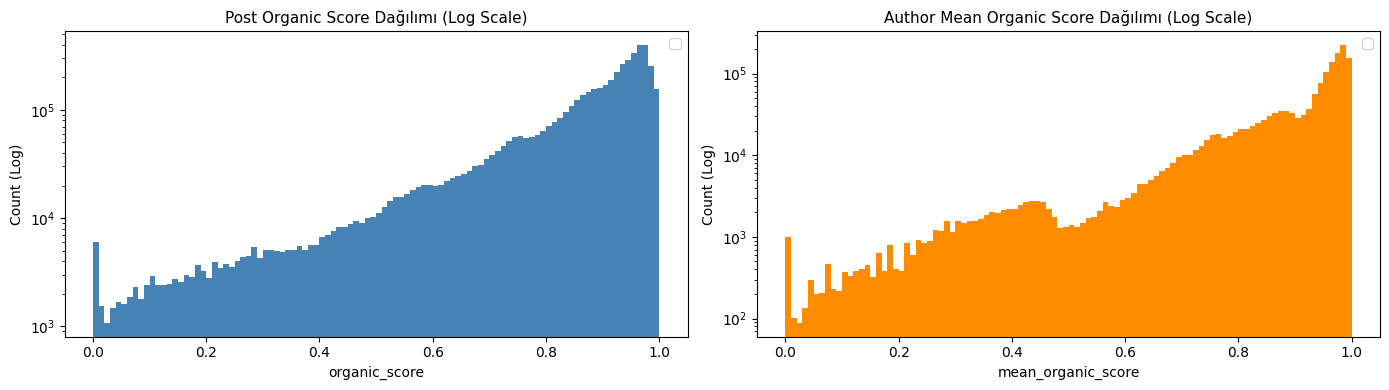


Post score   — mean: 0.8528  std: 0.1608
Author score — mean: 0.8889  std: 0.1443


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Percentile tablosu (Değişiklik yok)
pcts = [0, 1, 5, 10, 25, 50, 75, 90, 95, 99, 100]
post_pct   = np.percentile(post_scores["organic_score"], pcts)
author_pct = np.percentile(author_scores["mean_organic_score"], pcts)

pct_df = pd.DataFrame({
    "percentile": pcts,
    "post_score": post_pct.round(4),
    "author_score": author_pct.round(4),
})
display(pct_df)

# Histogram - LOG SCALE EKLENDİ
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# log=True parametresi Y eksenini logaritmik yapar
axes[0].hist(post_scores["organic_score"], bins=100, color="steelblue", edgecolor="none", log=True)
axes[0].set_title("Post Organic Score Dağılımı (Log Scale)", fontsize=11)
axes[0].set_xlabel("organic_score")
axes[0].set_ylabel("Count (Log)") # Eksen bilgisini güncelledik
axes[0].legend()

# log=True parametresi eklendi
axes[1].hist(author_scores["mean_organic_score"], bins=100, color="darkorange", edgecolor="none", log=True)
axes[1].set_title("Author Mean Organic Score Dağılımı (Log Scale)", fontsize=11)
axes[1].set_xlabel("mean_organic_score")
axes[1].set_ylabel("Count (Log)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nPost score   — mean: {post_scores['organic_score'].mean():.4f}  std: {post_scores['organic_score'].std():.4f}")
print(f"Author score — mean: {author_scores['mean_organic_score'].mean():.4f}  std: {author_scores['mean_organic_score'].std():.4f}")

In [5]:
test_df = pd.read_parquet(OUTPUTS_DIR / "post_scores.parquet")
print(test_df.columns.tolist())

['author_hash', 'organic_score', 'timestamp', 'language', 'domain']


## 2. Eşik Analizi

In [6]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.30]

rows = []
for t in thresholds:
    n_post   = (post_scores["organic_score"] < t).sum()
    n_author = (author_scores["mean_organic_score"] < t).sum()
    rows.append({
        "eşik": t,
        "şüpheli post": n_post,
        "şüpheli post %": round(n_post / len(post_scores) * 100, 2),
        "şüpheli author": n_author,
        "şüpheli author %": round(n_author / len(author_scores) * 100, 2),
    })

display(pd.DataFrame(rows))

,eşik,şüpheli post,şüpheli post %,şüpheli author,şüpheli author %
0,0.05,11777,0.24,1629,0.10
1,0.10,21750,0.43,2957,0.19
2,0.15,34630,0.69,4894,0.31
3,0.20,49948,1.00,7437,0.47
4,0.30,90085,1.80,17004,1.06


## 3. Bilinen Bot Validasyonu — 0a92fab3

EDA'dan: 35,280 post, 62 dil, medyan interval 1s, tüm 15 temayı kullanan tek author.  
Beklenti: `mean_organic_score` < 0.10

0a92fab3
  mean_organic_score : 0.4460  (✗ YANLIŞ — model botu kaçırdı)
  Sıralama           : 46,672 / 1,597,836  (alt %2.92)
  Post sayısı        : 35,280
  Post skor aralığı  : [0.0000, 0.6108]


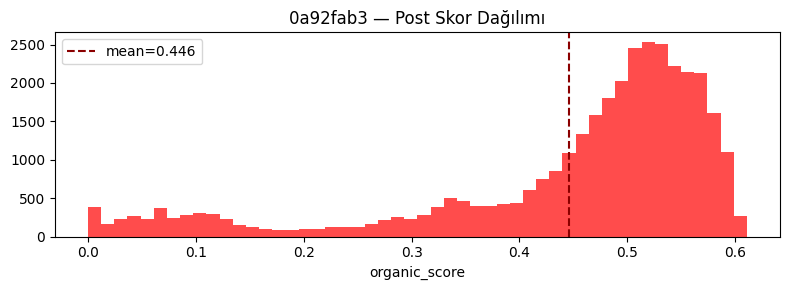

,değer
author_posts_per_day,3205.151473
author_min_interval_sec,0.000000
author_unique_themes,15.000000
author_duplicate_ratio,0.056264
author_sentiment_std,0.441873
author_mean_jaccard,0.007312


In [7]:
KNOWN_BOT = "0a92fab3"

bot_author = author_scores[author_scores["author_hash"].str.startswith(KNOWN_BOT)]
bot_posts  = post_scores[post_scores["author_hash"].str.startswith(KNOWN_BOT)]

if bot_author.empty:
    print(f"⚠  {KNOWN_BOT} author_scores'da bulunamadı — hash tam adını kontrol et.")
else:
    score = bot_author["mean_organic_score"].values[0]
    rank  = (author_scores["mean_organic_score"] <= score).sum()
    pct_rank = rank / len(author_scores) * 100

    verdict = "✓ DOĞRU" if score < 0.20 else "✗ YANLIŞ — model botu kaçırdı"
    print(f"{KNOWN_BOT}")
    print(f"  mean_organic_score : {score:.4f}  ({verdict})")
    print(f"  Sıralama           : {rank:,} / {len(author_scores):,}  (alt %{pct_rank:.2f})")
    print(f"  Post sayısı        : {len(bot_posts):,}")
    if not bot_posts.empty:
        print(f"  Post skor aralığı  : [{bot_posts['organic_score'].min():.4f}, {bot_posts['organic_score'].max():.4f}]")

    # Bu author'ın skor dağılımı
    if not bot_posts.empty:
        plt.figure(figsize=(8, 3))
        plt.hist(bot_posts["organic_score"], bins=50, color="red", alpha=0.7)
        plt.axvline(score, color="darkred", linestyle="--", label=f"mean={score:.3f}")
        plt.title(f"{KNOWN_BOT} — Post Skor Dağılımı")
        plt.xlabel("organic_score")
        plt.legend()
        plt.tight_layout()
        plt.show()

    # Author profil bilgileri
    profile_cols = [c for c in bot_author.columns if c not in ["author_hash", "mean_organic_score"]]
    if profile_cols:
        display(bot_author[profile_cols].T.rename(columns={bot_author.index[0]: "değer"}))

## 4. Feature → Skor Monotonluk Kontrolü

Beklenti: `cross_author_dup_count` ↑ → `organic_score` ↓  
Her feature için: grup bazlı ortalama skor + Spearman korelasyon

In [8]:
from scipy.stats import spearmanr

# post_df + post_scores birleştir (organic_score lazım)
# post_scores'ta index korunmamış olabilir — reset ile güvenli merge
merged = post_df[IF_FEATURES].copy()
merged["organic_score"] = post_scores["organic_score"].values

print("Spearman Korelasyon — Feature vs organic_score")
print("-" * 50)
corr_rows = []
for col in IF_FEATURES:
    rho, p = spearmanr(merged[col], merged["organic_score"])
    direction = "↑ skoru düşürür" if rho < -0.05 else ("→ nötr" if abs(rho) < 0.05 else "↑ skoru artırır")
    corr_rows.append({"feature": col, "spearman_rho": round(rho, 4), "p_value": round(p, 6), "yorum": direction})

corr_df = pd.DataFrame(corr_rows).sort_values("spearman_rho")
display(corr_df)

Spearman Korelasyon — Feature vs organic_score
--------------------------------------------------


,feature,spearman_rho,p_value,yorum
12,author_sentiment_std,-0.6239,0.0,↑ skoru düşürür
13,author_unique_themes,-0.5813,0.0,↑ skoru düşürür
11,author_mean_jaccard,-0.5276,0.0,↑ skoru düşürür
14,author_duplicate_ratio,-0.4063,0.0,↑ skoru düşürür
8,kw_fingerprint_shared,-0.3432,0.0,↑ skoru düşürür
4,sentiment_extreme,-0.2643,0.0,↑ skoru düşürür
9,author_posts_per_day,-0.2575,0.0,↑ skoru düşürür
5,is_duplicate,-0.2492,0.0,↑ skoru düşürür
7,cross_author_dup_count,-0.2492,0.0,↑ skoru düşürür
6,has_author,-0.2200,0.0,↑ skoru düşürür


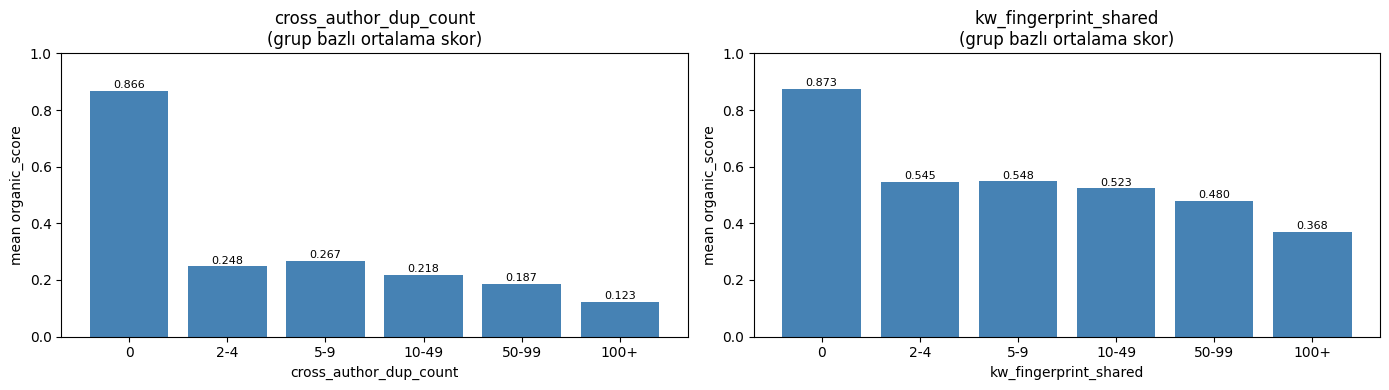

Beklenti: soldan sağa (dup sayısı arttıkça) skor düşmeli.


In [9]:
# Grup bazlı skor — cross_author_dup_count ve kw_fingerprint_shared için
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col in zip(axes, ["cross_author_dup_count", "kw_fingerprint_shared"]):
    bins = [0, 1, 2, 5, 10, 50, 100, merged[col].max() + 1]
    labels = ["0", "1", "2-4", "5-9", "10-49", "50-99", "100+"]
    merged["_bucket"] = pd.cut(merged[col], bins=bins, labels=labels, right=False)
    grp = merged.groupby("_bucket", observed=True)["organic_score"].mean()
    ax.bar(grp.index.astype(str), grp.values, color="steelblue")
    ax.set_title(f"{col}\n(grup bazlı ortalama skor)")
    ax.set_xlabel(col)
    ax.set_ylabel("mean organic_score")
    ax.set_ylim(0, 1)
    for i, v in enumerate(grp.values):
        ax.text(i, v + 0.01, f"{v:.3f}", ha="center", fontsize=8)

merged.drop(columns=["_bucket"], inplace=True)
plt.tight_layout()
plt.show()
print("Beklenti: soldan sağa (dup sayısı arttıkça) skor düşmeli.")

## 5. Stabilite Testi — Farklı Seed'lerde Top-1000 Overlap

Modelin deterministik olmayan kısmı tree construction.  
5 farklı seed → her seferinde aynı author'lar top-1000'e giriyor mu?  
> **Yöntem:** 150K post örneği üzerinde fit → top-%5 Jaccard overlap hesapla.  
> Jaccard > 0.80 → stabil kabul edilir.

In [10]:
SAMPLE_N = 150_000
SEEDS    = [42, 7, 123, 999, 2024]
TOP_K    = int(SAMPLE_N * 0.05)  # en anomal %5

sample = merged.sample(n=min(SAMPLE_N, len(merged)), random_state=42).reset_index(drop=True)

# log1p + scale (eğitimle aynı pipeline)
s_feat = sample[IF_FEATURES].copy()
for col in LOG1P_FEATURES:
    if col in s_feat.columns:
        s_feat[col] = np.log1p(s_feat[col])

top_sets = []
for seed in SEEDS:
    sc  = RobustScaler().fit_transform(s_feat.values)
    clf = IsolationForest(n_estimators=300, max_samples=10_000, contamination="auto",
                          random_state=seed, n_jobs=-1)
    clf.fit(sc)
    scores = clf.score_samples(sc)
    top_idx = set(np.argsort(scores)[:TOP_K])
    top_sets.append(top_idx)
    print(f"  seed={seed:4d}  → top-{TOP_K} hesaplandı")

# Pairwise Jaccard
ref = top_sets[0]  # seed=42
print(f"\nJaccard similarity — seed=42 referans alınarak:")
jaccards = []
for seed, s in zip(SEEDS[1:], top_sets[1:]):
    j = len(ref & s) / len(ref | s)
    jaccards.append(j)
    verdict = "✓" if j > 0.80 else "⚠"
    print(f"  seed={seed:4d}  Jaccard={j:.4f}  {verdict}")

print(f"\nOrt. Jaccard: {np.mean(jaccards):.4f}")
print("Yorum: >0.80 → model stabil, <0.80 → n_estimators artır veya seed sabitle.")

  seed=  42  → top-7500 hesaplandı
  seed=   7  → top-7500 hesaplandı
  seed= 123  → top-7500 hesaplandı
  seed= 999  → top-7500 hesaplandı
  seed=2024  → top-7500 hesaplandı

Jaccard similarity — seed=42 referans alınarak:
  seed=   7  Jaccard=0.9011  ✓
  seed= 123  Jaccard=0.9028  ✓
  seed= 999  Jaccard=0.9004  ✓
  seed=2024  Jaccard=0.9007  ✓

Ort. Jaccard: 0.9013
Yorum: >0.80 → model stabil, <0.80 → n_estimators artır veya seed sabitle.


## 6. Aynı Author İçi Skor Tutarlılığı

Aynı author'ın postları benzer skor almalı.  
Yüksek within-author std → model post-level gürültüyü çok büyütüyor demektir.

≥5 postlu author sayısı: 66,547

Within-author std_score:


,count,mean,std,min,25%,50%,75%,max
std_score,66547.0,0.0712,0.0626,0.0,0.0213,0.0417,0.1155,0.3464


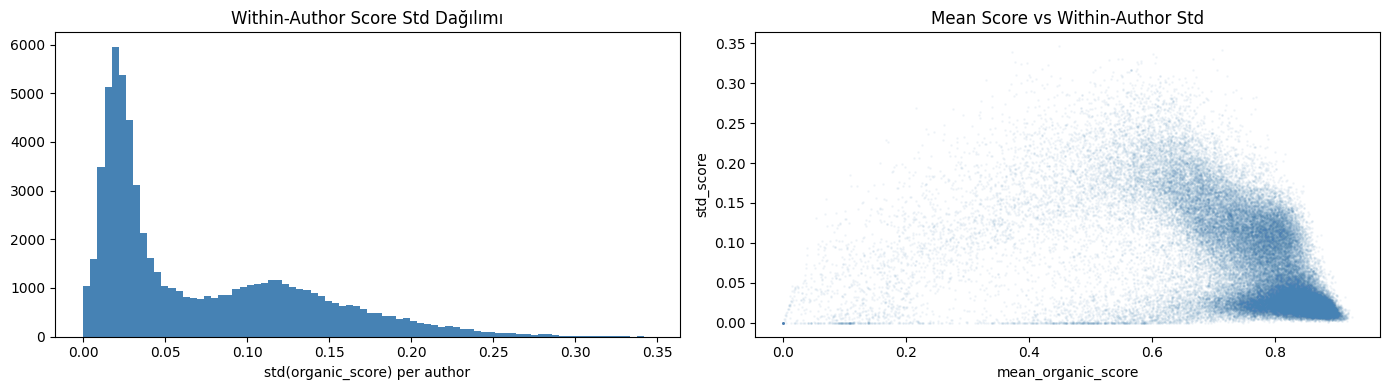

std > 0.20 olan author: 2,818 (4.2%)


In [11]:
# has_author=1 olan postlarla çalış
ps_with_author = post_scores[post_scores.get("has_author", post_scores["organic_score"].notna()) == 1].copy()
if "has_author" not in post_scores.columns:
    # has_author bilgisi yoksa post_df'ten al
    ps_with_author = post_scores.copy()
    ps_with_author["has_author"] = post_df["has_author"].values
    ps_with_author = ps_with_author[ps_with_author["has_author"] == 1]

author_consistency = (
    ps_with_author.groupby("author_hash")["organic_score"]
    .agg(["mean", "std", "count"])
    .reset_index()
    .rename(columns={"mean": "mean_score", "std": "std_score", "count": "post_count"})
)
# En az 5 postu olan authorları filtrele
author_consistency = author_consistency[author_consistency["post_count"] >= 5]
author_consistency["std_score"] = author_consistency["std_score"].fillna(0)

print(f"≥5 postlu author sayısı: {len(author_consistency):,}")
print(f"\nWithin-author std_score:")
display(author_consistency["std_score"].describe().round(4).to_frame().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(author_consistency["std_score"], bins=80, color="steelblue", edgecolor="none")
axes[0].set_title("Within-Author Score Std Dağılımı")
axes[0].set_xlabel("std(organic_score) per author")

axes[1].scatter(
    author_consistency["mean_score"],
    author_consistency["std_score"],
    alpha=0.05, s=1, color="steelblue"
)
axes[1].set_title("Mean Score vs Within-Author Std")
axes[1].set_xlabel("mean_organic_score")
axes[1].set_ylabel("std_score")

plt.tight_layout()
plt.show()

high_std = author_consistency[author_consistency["std_score"] > 0.2]
print(f"std > 0.20 olan author: {len(high_std):,} ({len(high_std)/len(author_consistency)*100:.1f}%)")

## 7. Top-1000 Bot Profili

Top botlar ile geri kalanın feature dağılımlarını karşılaştır.

Top-1000 bot mean score : 0.0009
Diğer author mean score : 0.8895


,top_1000_bot,diger_author,oran (bot/diger)
author_posts_per_day,2.0494,1.1232,1.82
author_min_interval_sec,57687.6820,89343.1851,0.65
author_unique_themes,1.0560,1.3545,0.78
author_duplicate_ratio,0.9894,0.0264,37.48
author_sentiment_std,0.0285,0.0808,0.35
author_mean_jaccard,0.3557,0.0117,30.40


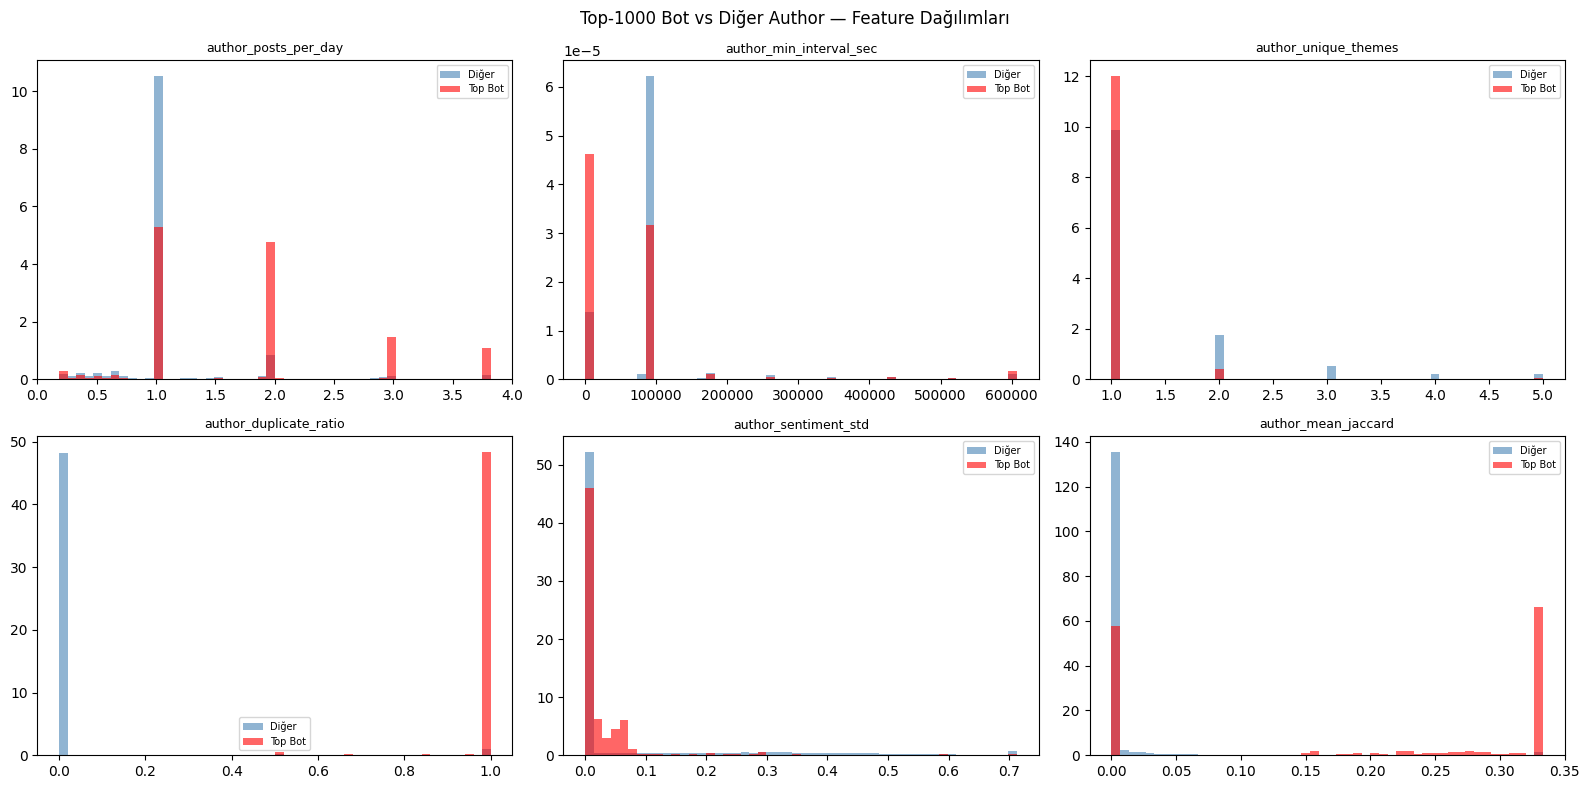

In [12]:
top_set   = set(top_bots["author_hash"])
other_set = set(author_scores[~author_scores["author_hash"].isin(top_set)]["author_hash"])

top_profiles   = author_scores[author_scores["author_hash"].isin(top_set)]
other_profiles = author_scores[author_scores["author_hash"].isin(other_set)]

print(f"Top-1000 bot mean score : {top_profiles['mean_organic_score'].mean():.4f}")
print(f"Diğer author mean score : {other_profiles['mean_organic_score'].mean():.4f}")

profile_numeric = [c for c in author_scores.columns
                   if c not in ["author_hash", "mean_organic_score"]
                   and pd.api.types.is_numeric_dtype(author_scores[c])]

if profile_numeric:
    compare = pd.DataFrame({
        "top_1000_bot": top_profiles[profile_numeric].mean().round(4),
        "diger_author" : other_profiles[profile_numeric].mean().round(4),
    })
    compare["oran (bot/diger)"] = (compare["top_1000_bot"] / compare["diger_author"].replace(0, np.nan)).round(2)
    display(compare)
    
    n_cols = min(len(profile_numeric), 6)
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()
    for i, col in enumerate(profile_numeric[:n_cols]):
        p99 = author_scores[col].quantile(0.99)
        axes[i].hist(other_profiles[col].clip(upper=p99), bins=50,
                     alpha=0.6, color="steelblue", label="Diğer", density=True)
        axes[i].hist(top_profiles[col].clip(upper=p99), bins=50,
                     alpha=0.6, color="red", label="Top Bot", density=True)
        axes[i].set_title(col, fontsize=9)
        axes[i].legend(fontsize=7)
    for j in range(n_cols, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle("Top-1000 Bot vs Diğer Author — Feature Dağılımları", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("author_scores'ta numeric profil kolonu bulunamadı.")

## 8. Feature–Skor Korelasyon (Vekil Önem Analizi)

IF'in native feature importance'ı yoktur.  
Vekil: her feature'ı tek tek sıfırla (median'a çek), skoru yeniden hesapla — skor ne kadar bozulduysa o feature o kadar önemli.

,feature,mean_score_change,relative_importance
0,sentiment,0.007112,15.15
1,has_author,0.006054,12.89
2,author_sentiment_std,0.005196,11.07
3,author_min_interval_sec,0.004352,9.27
4,kw_count,0.003739,7.96
5,text_len,0.003537,7.53
6,kw_density,0.003215,6.85
7,author_unique_themes,0.003007,6.40
8,sentiment_extreme,0.002451,5.22
9,kw_fingerprint_shared,0.002193,4.67


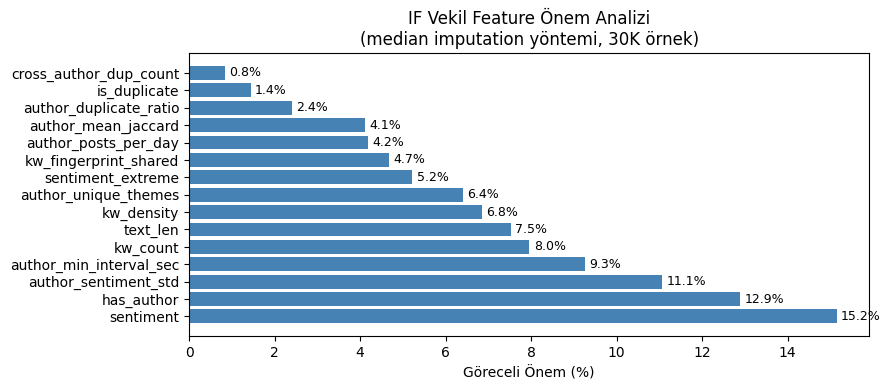

In [13]:
PERMUTATION_SAMPLE = 30_000

sample2 = post_df[IF_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0).sample(
    n=min(PERMUTATION_SAMPLE, len(post_df)), random_state=42
).reset_index(drop=True)

# Baseline pipeline
def get_scores(df_feat):
    X = df_feat.copy()
    for col in LOG1P_FEATURES:
        if col in X.columns:
            X[col] = np.log1p(X[col])
    X_sc = scaler.transform(X.values)
    return iso_forest.score_samples(X_sc)

baseline_scores = get_scores(sample2)
baseline_mean   = baseline_scores.mean()

importance = {}
for col in IF_FEATURES:
    perturbed = sample2.copy()
    perturbed[col] = sample2[col].median()  # median'a çek
    perturbed_scores = get_scores(perturbed)
    # Skor değişimi — büyük sapma = önemli feature
    importance[col] = abs(baseline_scores - perturbed_scores).mean()

imp_df = pd.DataFrame(list(importance.items()), columns=["feature", "mean_score_change"])
imp_df = imp_df.sort_values("mean_score_change", ascending=False).reset_index(drop=True)
imp_df["mean_score_change"] = imp_df["mean_score_change"].round(6)
imp_df["relative_importance"] = (imp_df["mean_score_change"] / imp_df["mean_score_change"].sum() * 100).round(2)

display(imp_df)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(imp_df["feature"], imp_df["relative_importance"], color="steelblue")
ax.set_xlabel("Göreceli Önem (%)")
ax.set_title("IF Vekil Feature Önem Analizi\n(median imputation yöntemi, 30K örnek)")
for bar, val in zip(bars, imp_df["relative_importance"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()